# Train model1 with GPT2's embeddings

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader, random_split

# GPT-2's tokenizer
from transformers import GPT2Tokenizer, AutoModelForCausalLM

/Users/shre/courses/llm_deep_dive/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# data hyperparameters
seq_len = 8 # aka context length
stride = 2

# model hyperparameters
embed_dim = 768

# training hyperparameters
batch_size = 64

## Data and model

In [4]:
# import and tokenize the text
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )

Token indices sequence length is longer than the specified maximum sequence length for this model (48533 > 1024). Running this sequence through the model will result in indexing errors


In [5]:
# create a class for a dataset (note: batching is done by the DataLoader, not in the dataset)
class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len=8, stride=4) -> None:
        # initialize
        self.inputs = []
        self.targets = []

        # overlapping sequences of seq_len
        for i in range(0, len(tokens)-seq_len, stride):
            # get c tokens and append to lists
            self.inputs.append(tokens[i: i+seq_len])
            self.targets.append(tokens[i+1 : i+1+seq_len])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

In [6]:
# create an instance
token_dataset = TokenDataset(tmTokens, seq_len, stride)

# split into train and test
train_ratio = .9
train_size = int(train_ratio * len(token_dataset))
test_size = len(token_dataset) - train_size

# create train/test subset
train_dataset, test_dataset = random_split(token_dataset, [train_size, test_size])

# create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train set has {train_size:5} sequences.')
print(f'Test set has  {test_size:5} sequences.')

Train set has 21836 sequences.
Test set has   2427 sequences.


## the model

In [7]:
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        # embedding matrix
        self.embedding = nn.Embedding(tokenizer.vocab_size, embed_dim)

        # embedding to output layer
        self.gelu = nn.GELU()
        self.finalLinear = nn.Linear(embed_dim, tokenizer.vocab_size)
    
    def forward(self, tokx):
        # forward pass
        x = self.embedding(tokx) # [batch, token, embeddings]
        x = self.gelu(x)
        x = self.finalLinear(x) # [embeddings, vocab]

        # return lof-softmax
        return F.log_softmax(x,dim=-1)
    
    def generate(self, tokx, n_new_tokens = 30):
        for _ in range(n_new_tokens):
            x = self(tokx)
            x = x[:, -1, :]
            probs = torch.exp(x) # undo the log but keep the softmax
            nextToken = torch.multinomial(probs, num_samples=1)
            tokx = torch.cat( (tokx,nextToken),dim=1)
        
        return tokx

## Copy GPT2's embeddings onto Model1

In [8]:
# import the GPT2 small model
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')

In [9]:
model = Model()

In [10]:
# check that the sizes match
print(f'My model embedding:   {model.embedding.weight.shape}')
print(f'GPT2 model embedding: {gpt2.transformer.wte.weight.shape}')

My model embedding:   torch.Size([50257, 768])
GPT2 model embedding: torch.Size([50257, 768])


In [11]:
# and copy over
model.embedding.weight.data = gpt2.transformer.wte.weight.data

In [12]:
# check for equality
model.embedding.weight[0] - gpt2.transformer.wte.weight[0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

## Train the model with frozen embeddings

In [13]:
# initial state
print(model.embedding.weight.requires_grad)

True


In [14]:
# switch it off
model.embedding.weight.requires_grad = False

# confirm
print(model.embedding.weight.requires_grad)

False


## Prepare for training

In [15]:
# push the model to the GPU
model = model.to(device)

# create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

## Now train the model!

In [16]:
num_epochs = 10

# initialize losses
train_loss = []
test_loss = []

for epoch in range(num_epochs):

    # initialize
    epoch_loss = 0

    # loop over batches in the data loader
    for X,y in train_dataloader:

        # move data to GPU
        X,y = X.to(device), y.to(device)

        # clear previous gradients
        model.zero_grad()

        # forward pass
        log_probs = model(X)

        # calculate the losses on the (reshaped) final target word
        log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1])
        y_flat = y[:,1:].reshape(-1)
        loss = loss_function(log_probs_flat, y_flat)

        # backprop
        loss.backward()
        optimizer.step()

        # sum the per-epoch losses
        epoch_loss += loss.item()
    #- loop over batches ends here


    # evaluate the model with the test set
    with torch.no_grad():
        testloss = 0 # reset the test loss
        for X,y in test_dataloader:
            X,y = X.to(device), y.to(device)  # push it to the GPU
            out = model(X)                    # forward pass
            out_flat = out[:,:-1,:].reshape(-1,out.shape[-1]) # reshape output
            y_flat = y[:,1:].reshape(-1)     # reshape targets
            thisloss = loss_function(out_flat, y_flat) # calculate loss
            testloss += thisloss.item()



    # scale the train loss by the number of tokens in this dataloader
    train_loss.append(epoch_loss / len(train_dataloader))
    test_loss.append(testloss / len(test_dataloader))

    # update our progress :)
    print(f'Epoch {epoch+1:2}, train loss: {epoch_loss / len(train_dataloader):.4f}, test loss: {testloss/len(test_dataloader):.4f}')

Epoch  1, train loss: 8.3993, test loss: 6.6174
Epoch  2, train loss: 5.9743, test loss: 5.6804
Epoch  3, train loss: 5.4669, test loss: 5.4220
Epoch  4, train loss: 5.2174, test loss: 5.2390
Epoch  5, train loss: 5.0182, test loss: 5.0878
Epoch  6, train loss: 4.8521, test loss: 4.9590
Epoch  7, train loss: 4.7108, test loss: 4.8482
Epoch  8, train loss: 4.5918, test loss: 4.7536
Epoch  9, train loss: 4.4935, test loss: 4.6727
Epoch 10, train loss: 4.4111, test loss: 4.6011


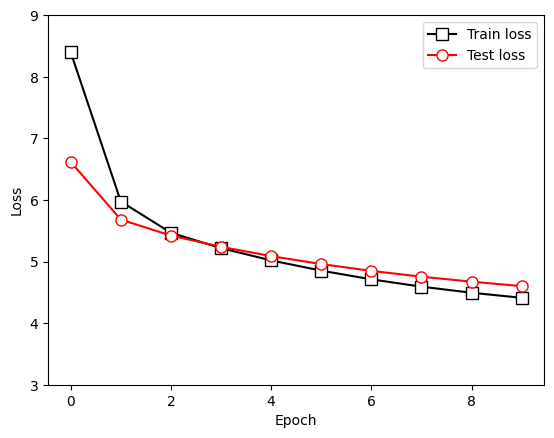

In [17]:
# plot the losses
plt.plot(train_loss, 'ks-', markerfacecolor='w', markersize=8, label='Train loss')
plt.plot(test_loss, 'ro-', markerfacecolor='w', markersize=8, label='Test loss')

plt.legend()
plt.gca().set(xlabel='Epoch', ylabel='Loss', ylim=[3,9])
plt.show()